In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mineralization_25k_ngdr_20250224141143411.dbf to mineralization_25k_ngdr_20250224141143411.dbf
Saving mineralization_25k_ngdr_20250224141143411.prj to mineralization_25k_ngdr_20250224141143411.prj
Saving mineralization_25k_ngdr_20250224141143411.shp to mineralization_25k_ngdr_20250224141143411.shp
Saving mineralization_25k_ngdr_20250224141143411.shx to mineralization_25k_ngdr_20250224141143411.shx


In [ ]:
import geopandas as gpd


gdf = gpd.read_file("mineralization_25k_ngdr_20250224141143411.shp")  # Don't include the other extensions


In [ ]:
gdf.columns

Index(['gid', 'input_cent', 'edition_no', 'toposheet_', 'commodity',
       'descriptio', 'accession_', 'remarks', 'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         17 non-null     int32   
 1   input_cent  17 non-null     object  
 2   edition_no  17 non-null     int32   
 3   toposheet_  17 non-null     object  
 4   commodity   17 non-null     object  
 5   descriptio  0 non-null      object  
 6   accession_  0 non-null      object  
 7   remarks     0 non-null      object  
 8   geometry    17 non-null     geometry
dtypes: geometry(1), int32(2), object(6)
memory usage: 1.2+ KB


In [ ]:
gdf.shape


(17, 9)

In [ ]:
gdf.describe()

,gid,edition_no
count,17.000000,17.0
mean,102.823529,1.0
std,28.317917,0.0
min,77.000000,1.0
25%,83.000000,1.0
50%,87.000000,1.0
75%,119.000000,1.0
max,166.000000,1.0


In [ ]:
gdf.head()



,gid,input_cent,edition_no,toposheet_,commodity,descriptio,accession_,remarks,geometry
0,77,SR,1,57B08,Copper,None,None,None,POINT (76.4441 14.14972)
1,80,SR,1,57E11,Diamond,None,None,None,POINT (77.58692 15.28887)
2,81,SR,1,57E11,Diamond,None,None,None,POINT (77.59776 15.29494)
3,82,SR,1,57E11,Diamond,None,None,None,POINT (77.59186 15.28002)
4,83,SR,1,57E11,Diamond,None,None,None,POINT (77.59679 15.28057)


✅ Initial Columns: ['gid', 'input_cent', 'edition_no', 'toposheet_', 'commodity', 'descriptio', 'accession_', 'remarks', 'geometry']
   gid input_cent  edition_no toposheet_ commodity descriptio accession_  \
0   77         SR           1      57B08    Copper       None       None   
1   80         SR           1      57E11   Diamond       None       None   
2   81         SR           1      57E11   Diamond       None       None   
3   82         SR           1      57E11   Diamond       None       None   
4   83         SR           1      57E11   Diamond       None       None   

  remarks                   geometry  
0    None   POINT (76.4441 14.14972)  
1    None  POINT (77.58692 15.28887)  
2    None  POINT (77.59776 15.29494)  
3    None  POINT (77.59186 15.28002)  
4    None  POINT (77.59679 15.28057)  
🚫 Dropping column: input_cent
🚫 Dropping column: edition_no
🚫 Dropping column: descriptio
🚫 Dropping column: accession_
🚫 Dropping column: remarks

✅ Cleaned dataset saved to: 

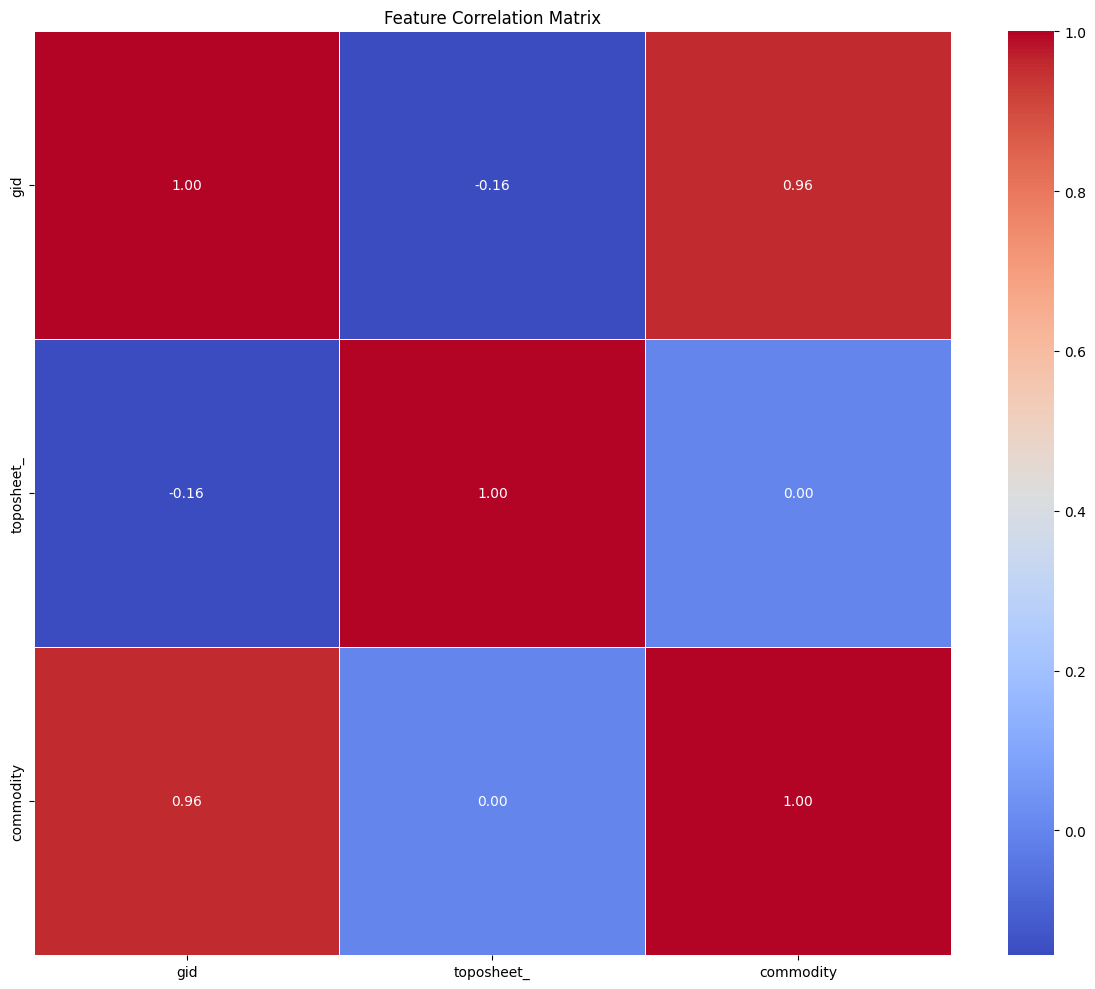


🔍 Correlation of features with target:
gid           9.559192e-01
toposheet_    1.226917e-16
Name: commodity, dtype: float64

📊 Random Forest Evaluation:
   RMSE       : 0.5361
   R² Score   : 0.7580
   Accuracy   : 75.80%

📊 XGBoost Evaluation:
   RMSE       : 0.7073
   R² Score   : 0.5787
   Accuracy   : 57.87%

📊 Gradient Boosting Evaluation:
   RMSE       : 0.5000
   R² Score   : 0.7895
   Accuracy   : 78.95%

🏆 Best Model: Gradient Boosting with Accuracy: 78.95%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------- Load Shapefile ----------------------------
shapefile_path = "mineralization_25k_ngdr_20250224141143411.shp"
gdf = gpd.read_file(shapefile_path)

print("✅ Initial Columns:", gdf.columns.tolist())
print(gdf.head())

# ---------------------------- Clean Data ----------------------------

if "geometry" in gdf.columns:
    gdf.drop(columns=["geometry"], inplace=True)

# Drop uninformative columns
for col in gdf.columns:
    if gdf[col].nunique() <= 1 or gdf[col].isnull().sum() == len(gdf):
        print(f"🚫 Dropping column: {col}")
        gdf.drop(columns=[col], inplace=True)

# Drop irrelevant ID columns
irrelevant_cols = ["accession_", "remarks", "objectid", "id", "uuid", "fid"]
gdf.drop(columns=[col for col in irrelevant_cols if col in gdf.columns], errors="ignore", inplace=True)

# Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].mean())

# Label encode categorical columns
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col].astype(str))

# Save cleaned data
cleaned_csv_path = "cleaned_mineralization_data.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"\n✅ Cleaned dataset saved to: {cleaned_csv_path}")
print(f"📊 Shape after cleaning: {gdf.shape}")
print("📌 Cleaned Columns:", gdf.columns.tolist())

# ---------------------------- Correlation Matrix ----------------------------

plt.figure(figsize=(12, 10))
sns.heatmap(gdf.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# ---------------------------- Feature Selection ----------------------------

# Target column
target_column = "shape_leng" if "shape_leng" in gdf.columns else gdf.columns[-1]
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# Show correlation of features with target
correlations = gdf.corr()[target_column].drop(target_column).sort_values(ascending=False)
print("\n🔍 Correlation of features with target:")
print(correlations)

# ---------------------------- Standardize Data ----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# ---------------------------- Train-Test Split ----------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------- Model Training ----------------------------

rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# ---------------------------- Predictions ----------------------------

y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# ---------------------------- Evaluation Function ----------------------------

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    accuracy = r2 * 100
    print(f"\n📊 {model_name} Evaluation:")
    print(f"   RMSE       : {rmse:.4f}")
    print(f"   R² Score   : {r2:.4f}")
    print(f"   Accuracy   : {accuracy:.2f}%")
    return accuracy

# ---------------------------- Model Evaluation ----------------------------

acc_rf = evaluate(y_test, y_pred_rf, "Random Forest")
acc_xgb = evaluate(y_test, y_pred_xgb, "XGBoost")
acc_gb = evaluate(y_test, y_pred_gb, "Gradient Boosting")

# ---------------------------- Best Model ----------------------------

best_model = max([(acc_rf, "Random Forest"), (acc_xgb, "XGBoost"), (acc_gb, "Gradient Boosting")])
print(f"\n🏆 Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")
